In [1]:
# Cell 1 — Setup plotting and state
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt2
import matplotlib.pyplot as plt3
import numpy as np
from matplotlib.lines import Line2D
from moveit_msgs.msg import DisplayTrajectory
from mpl_toolkits.mplot3d import Axes3D
from sensor_msgs.msg import Imu, NavSatFix
from std_msgs.msg import Float32
from telehandler_moveit.msg import (MoveToPositionAction,
                                    MoveToPositionActionGoal,
                                    MoveToPositionGoal)

# These will live in memory as you re-run Cell 2
run_times = []     # list of all measured times
run_count = 0      # how many times you've run the script

pos_xs = []    # X positions
pos_ys = []    # Y positions
pos_zs = []    # Z positions

trajectory_data : DisplayTrajectory = None
goal_data : MoveToPositionActionGoal = None
planning_time_data = None

In [2]:
#! /usr/bin/env python3
# -*- coding: utf-8 -*-

import select
import sys
import time

import actionlib
import keyboard
#%% Imports
import rospy
from moveit_msgs.msg import DisplayTrajectory
from sensor_msgs.msg import Imu, NavSatFix
from std_msgs.msg import Float32
from telehandler_moveit.msg import (MoveToPositionAction,
                                    MoveToPositionActionGoal,
                                    MoveToPositionGoal)

# Trajectory Path Planning KPI Timer Monitoring
_planning_time_topic = '/planning_time'
_display_trajectory_topic = '/ugv0/telehandler/move_group/display_planned_path'
_goal_action_topic = '/ugv0/telehandler/action/MoveToPosition'

#%% KPI Timer Monitoring    

rospy.init_node('kpi_scripts_ipynb', anonymous=True, disable_signals=True)

trajectory_data : DisplayTrajectory = None
goal_data : MoveToPositionActionGoal = None


def get_display_trajectory_data(msg):
    global trajectory_data
    trajectory_data = msg
    return trajectory_data

def get_planning_time_data(msg):
    global planning_time_data
    planning_time_data = msg
    return planning_time_data

_goal_action_client = actionlib.SimpleActionClient(_goal_action_topic, MoveToPositionAction)

rospy.Subscriber(_planning_time_topic, Float32, get_planning_time_data)
rospy.Subscriber(_display_trajectory_topic, DisplayTrajectory, get_display_trajectory_data)

rospy.loginfo("Waiting for goal action server...")
if not _goal_action_client.wait_for_server(rospy.Duration(10)):
    raise RuntimeError("MoveToPositionAction server not available after 5s. Is it running?")
rospy.loginfo("Goal action server found")



def generate_goal_data():
    # {'data': '-0.852'}, {'data': 3.187'}, {'data': '8.5'}
    global goal_data
    goal_data = MoveToPositionGoal()
    goal_data.predefined_pose = ""
    goal_data.target_pose.header.frame_id = "base_link"
    goal_data.target_pose.header.stamp = rospy.Time.now()
    goal_data.target_pose.pose.position.x = 8.00
    goal_data.target_pose.pose.position.y = -6.0
    goal_data.target_pose.pose.position.z = 8.5
    goal_data.target_pose.pose.orientation.x = 0
    goal_data.target_pose.pose.orientation.y = 0
    goal_data.target_pose.pose.orientation.z = 0
    goal_data.target_pose.pose.orientation.w = 1.0
    return goal_data
    
_goal = generate_goal_data()
_goal_action_client.send_goal(_goal)       



while trajectory_data is None and planning_time_data is None:
    ready, _, _ = select.select([sys.stdin], [], [], 0.1)
    if ready:
        line = sys.stdin.readline().strip()
        if line.lower() == 'q' or line.lower() == "exit" or line.lower() == "logout":
            print("Loop aborted by user")
            raise KeyboardInterrupt
        
# Log into our globals
run_count   += 1

time.sleep(2)
# print(trajectory_data)
print(planning_time_data)
run_times.append(planning_time_data.data)
# print(trajectory_data)

# for i in trajectory_data:
#     print(i)

# grab the goal XYZ
px = _goal.target_pose.pose.position.x
py = _goal.target_pose.pose.position.y
pz = _goal.target_pose.pose.position.z

pos_xs.append(px)
pos_ys.append(py)
pos_zs.append(pz)

# Print a friendly summary
print(f"Run #{run_count} — Total time: {planning_time_data.data:.4f} s")

[INFO] [/kpi_scripts_ipynb_378097_1751538296620] [<module>] [47]: Waiting for goal action server...
[INFO] [/kpi_scripts_ipynb_378097_1751538296620] [<module>] [50]: Goal action server found
data: 0.04047911614179611
Run #1 — Total time: 0.0405 s


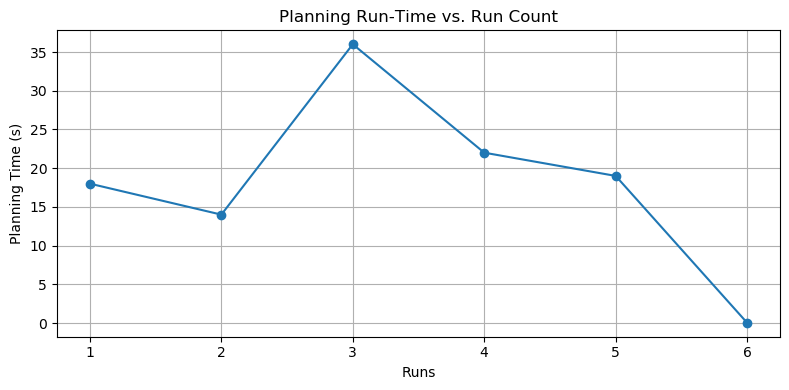

In [3]:
# Cell 3 — Plot all runs so far
x = list(range(1, run_count + 1))
y = run_times

plt.figure(figsize=(8, 4))
plt.plot(x, y, marker='o', linestyle='-')
plt.title("Planning Run-Time vs. Run Count")
plt.xlabel("Runs")
plt.ylabel("Planning Time (s)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
fig = plt2.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

# Your data arrays
X = np.array(pos_xs)
Y = np.array(pos_ys)
Z = np.array(pos_zs)

# Normalization helper
def normalize(arr, vmin, vmax):
    span = vmax - vmin
    return (arr - vmin) / span if span != 0 else np.zeros_like(arr)

# RGB mapping per axis
normX = normalize(X, X.min(), X.max())
normY = normalize(Y, Y.min(), Y.max())
normZ = normalize(Z,    0,    Z.max())   # ground at 0
colors = np.vstack((normX, normY, normZ)).T

# Scatter plot
scatter = ax.scatter(Y, X, Z, c=colors, marker='o', s=70)

# Draw projection lines for each point:
#  - down to Z=0 (XY‐plane)
#  - to Y=0 (XZ‐plane)
#  - to X=0 (YZ‐plane)
for i, (xi, yi, zi) in enumerate(zip(X, Y, Z)):
    c = colors[i]
    # Vertical down to XY-plane
    ax.plot([yi, yi], [xi, xi], [0, zi],
            linestyle='-', linewidth=1, color=c)
    # Back to XZ-plane (y=0)
    ax.plot([yi, yi], [0, xi], [zi, zi],
            linestyle='-', linewidth=1, color=c)
    # Over to YZ-plane (x=0)
    ax.plot([0, yi], [xi, xi], [zi, zi],
            linestyle='-', linewidth=1, color=c)

# Build legend handles and labels
handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=colors[i], markersize=8)
    for i in range(len(X))
]
labels = [f"[{X[i]:.2f}, {Y[i]:.2f}, {Z[i]:.2f}]" for i in range(len(X))]

ax.legend(handles, labels,
          title="Points (X, Y, Z)",
          loc='best', fontsize=12, title_fontsize=9)

# Center X/Y around 0, and set Z from 0 to its max
lim_xy = max(np.max(np.abs(X)), np.max(np.abs(Y)))
ax.set_ylim(-lim_xy, lim_xy)
ax.set_xlim(-lim_xy, lim_xy)
ax.set_zlim(0, np.max(Z))

# Labels & title
ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.set_zlabel("Z Position (ground = 0)")
ax.set_title("3D Goal-Position Scatter (RGB) with Projection Lines")

plt2.tight_layout()
plt2.show()

In [ ]:

# Prepare 1D & 3D data
x = np.arange(1, run_count + 1)
y = np.array(run_times)
X = np.array(pos_xs)
Y = np.array(pos_ys)
Z = np.array(pos_zs)

# Normalize for RGB mapping
def normalize(arr, vmin, vmax):
    span = vmax - vmin
    return (arr - vmin) / span if span != 0 else np.zeros_like(arr)

normX = normalize(X, X.min(), X.max())
normY = normalize(Y, Y.min(), Y.max())
normZ = normalize(Z,    0,    Z.max())
colors = np.vstack((normX, normY, normZ)).T  # shape (N,3)

# Create a wide figure with two subplots
fig = plt3.figure(figsize=(16, 6))

# ——— 2D run-time plot on the left ———
ax1 = fig.add_subplot(1, 2, 1)
# Optional line in gray for trend
ax1.plot(x, y, color='lightgray', linestyle='-')
# Colored markers matching 3D
ax1.scatter(x, y, c=colors, marker='o', s=70)
ax1.set_title("Planning Run-Time vs. Run Count")
ax1.set_xlabel("Run #")
ax1.set_ylabel("Time (ms)")
ax1.grid(True)

# ——— 3D scatter + projections on the right ———
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
scatter = ax2.scatter(Y, X, Z, c=colors, marker='o', s=70)

# Projection lines
for i, (xi, yi, zi) in enumerate(zip(X, Y, Z)):
    c = colors[i]
    ax2.plot([yi, yi], [xi, xi], [0, zi], linestyle='--', color=c)
    ax2.plot([yi, yi], [0, xi], [zi, zi], linestyle='--', color=c)
    ax2.plot([0, yi], [xi, xi], [zi, zi], linestyle='--', color=c)

# Legend for 3D points
handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=colors[i], markersize=8)
    for i in range(len(X))
]
labels = [f"[{X[i]:.2f}, {Y[i]:.2f}, {Z[i]:.2f}]" for i in range(len(X))]
ax2.legend(handles, labels, title="(X, Y, Z)", loc='best', fontsize=9, title_fontsize=10)

# Center X/Y, ground at Z=0
lim_xy = max(np.max(np.abs(X)), np.max(np.abs(Y)))
ax2.set_xlim(-lim_xy, lim_xy)
ax2.set_ylim(-lim_xy, lim_xy)
ax2.set_zlim(0, np.max(Z))

ax2.set_xlabel("X Position")
ax2.set_ylabel("Y Position")
ax2.set_zlabel("Z Position (ground = 0)")
ax2.set_title("3D Goal-Position Scatter (RGB)")

plt3.tight_layout()
plt3.show()